<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>

## Define Problem Statement and Objectives

## Import all the necessary libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user
#I will be installing the current versions of all libraries

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

## Reading the Data into a DataFrame

In [3]:
#mount my Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#load the data file
path = "/content/drive/MyDrive/UT DS Grad Cert/Project2/"
df = pd.read_csv(path + "abtest.csv")

## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [5]:
#This code block pulls the header and footer of the data to ensure proper loading
#It also pulls the shad and data types
#finally it summarizes the numeric variables
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("Data Header")
print(df.head())
print("\nData Tail")
print(df.tail())
print("\nData Shape")
print(df.shape)
print("\nData Summary")
print(df.describe())
print("\nData Types")
print(df.info())
#

Data Header
   user_id      group landing_page  time_spent_on_the_page converted language_preferred
0   546592    control          old                    3.48        no            Spanish
1   546468  treatment          new                    7.13       yes            English
2   546462  treatment          new                    4.40        no            Spanish
3   546567    control          old                    3.02        no             French
4   546459  treatment          new                    4.75       yes            Spanish

Data Tail
    user_id      group landing_page  time_spent_on_the_page converted language_preferred
95   546446  treatment          new                    5.15        no            Spanish
96   546544    control          old                    6.52       yes            English
97   546472  treatment          new                    7.07       yes            Spanish
98   546481  treatment          new                    6.20       yes            Spanish
99  

####Data Overview
There are 100 observations over six variables.  There are four string variables: group, landing_page, converted, and language_preferred.  There are two numeric variables: user id and time spent on the page.  Of these, User ID is actually treated as a categorical variable.  For the combined data, the mean time spent on the page is 5.378 minutes with a standard deviation of 2.378 minutes.

In [6]:
#check for missing values
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


In [7]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

#### Data Insights
There are no missing or null values.  Additionally, there are no duplicated entries.

### Univariate Analysis

#### Numeric Analysis

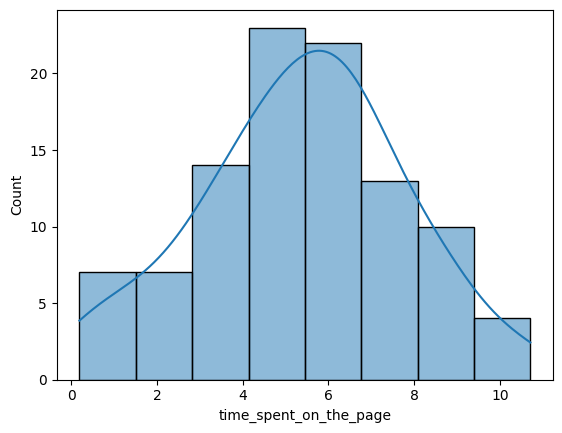

,time_spent_on_the_page
count,100.000000
mean,5.377800
std,2.378166
min,0.190000
25%,3.880000
50%,5.415000
75%,7.022500
max,10.710000


In [8]:
#create a histogram for the time spent on the page
sns.histplot(data = df, x ='time_spent_on_the_page', kde=True)
plt.show()
df['time_spent_on_the_page'].describe()

##### Data Insights
The time spent on the page is approximately normal with a mean of 5.378 minutes and a standard deviation of 2.378 minutes.  However, this is true of both groups combined.  Subsetting them may provide further insights.

In [9]:
#Subsetting the data in by group type
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']
#verifying data frames were made
print(control.head())
print(treatment.head())
#verifying sort was valid
print(control["group"].value_counts())
print(treatment["group"].value_counts())




   user_id    group landing_page  time_spent_on_the_page converted language_preferred
0   546592  control          old                    3.48        no            Spanish
3   546567  control          old                    3.02        no             French
5   546558  control          old                    5.28       yes            English
7   546581  control          old                    6.53       yes            Spanish
9   546548  control          old                    2.08        no            English
   user_id      group landing_page  time_spent_on_the_page converted language_preferred
1   546468  treatment          new                    7.13       yes            English
2   546462  treatment          new                    4.40        no            Spanish
4   546459  treatment          new                    4.75       yes            Spanish
6   546448  treatment          new                    5.25       yes             French
8   546461  treatment          new          

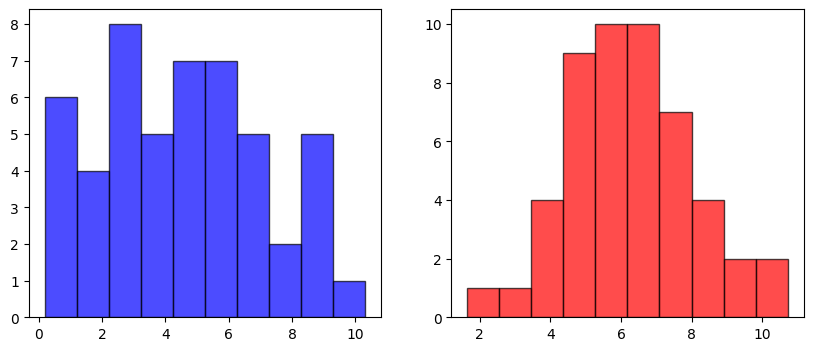

In [10]:
# creating histograms for both groups
# Plotting side-by-side
fig, (ctrl, trt) = plt.subplots(1, 2, figsize=(10, 4))
ctrl.hist(control['time_spent_on_the_page'], alpha = 0.7, label = 'control', color = "blue", edgecolor = "black")
trt.hist(treatment['time_spent_on_the_page'], alpha = 0.7, label = 'treatment', color = "red", edgecolor = "black")
plt.show()


In [11]:
#Summary statistics for the control and treatment groups
print("Control Group")
print(control['time_spent_on_the_page'].describe())
print("\nTreatment Group")
print(treatment['time_spent_on_the_page'].describe())

Control Group
count    50.000000
mean      4.532400
std       2.581975
min       0.190000
25%       2.720000
50%       4.380000
75%       6.442500
max      10.300000
Name: time_spent_on_the_page, dtype: float64

Treatment Group
count    50.000000
mean      6.223200
std       1.817031
min       1.650000
25%       5.175000
50%       6.105000
75%       7.160000
max      10.710000
Name: time_spent_on_the_page, dtype: float64


In [12]:
#calculating the variance of each group
con_var = 2.581975**2
treat_var = 1.817031**2
print(f"Control Variance: {con_var}")
print(f"Treatment Variance: {treat_var}")

Control Variance: 6.666594900624999
Treatment Variance: 3.3016016549610003


##### Data Insights
Once the data has been separated into two groups based on group type, a difference appears.  The time spent on page for the treatment group is approximately normal, with a mean of 6.223 minutes and a standard deviation of 1.817 minutes.  The time spent on the page for the control group is much more varied.  The shape is slightly right skewed with a mean of 4.532 minutes and a standard deviation of 2.582 minutes.  Overall, there is a visual distinction between the groups, but it is not yet clear whether this is statistically significant.

#### Categorical Analysis

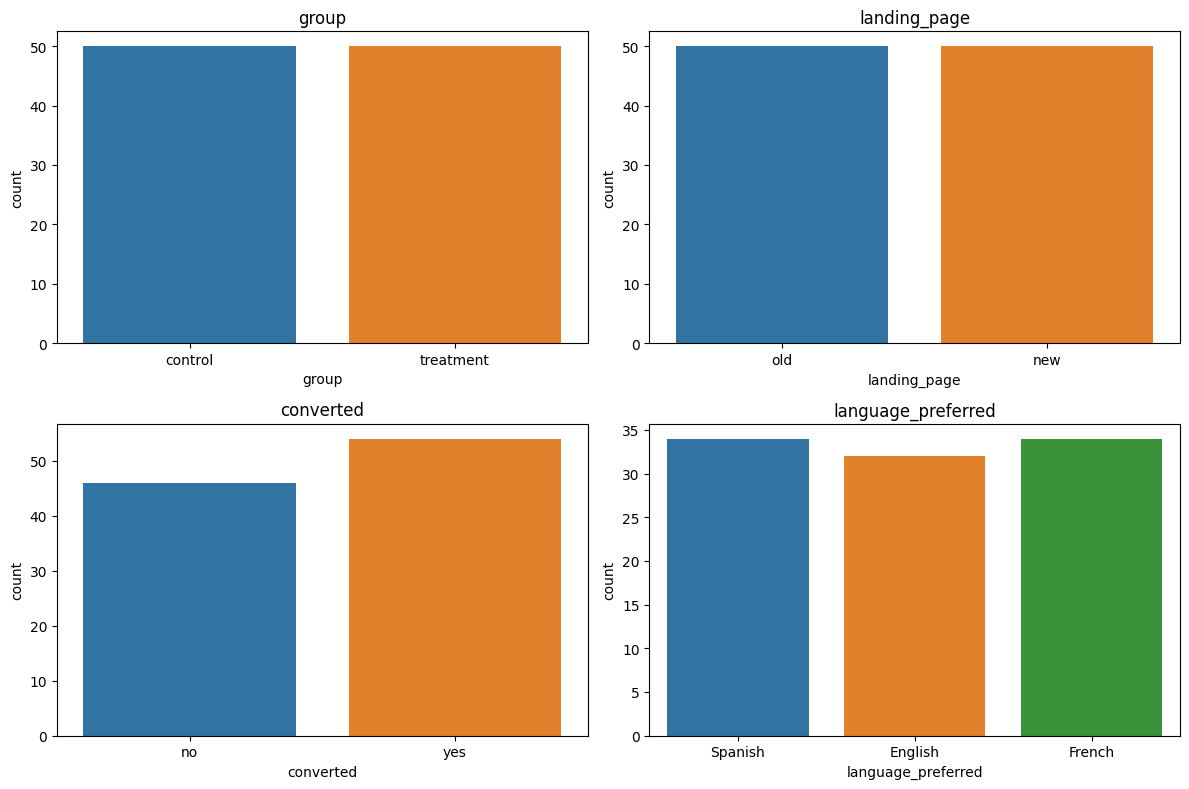

In [13]:
#set the size of the plot area for easier readability
cat_columns = ['group', 'landing_page', 'converted', 'language_preferred']
plt.figure(figsize=(12, 8))

#looping through each of the categorical columns and creating a separate bargraph for each
for i, variable in enumerate(cat_columns):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data = df, x = variable, hue = variable)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [14]:
#loop through each of the categorical columns and get the percentage of responses for each
for variable in cat_columns:
  print(f"{variable}:  {df[variable].value_counts(normalize=True)}")


group:  group
control      0.5
treatment    0.5
Name: proportion, dtype: float64
landing_page:  landing_page
old    0.5
new    0.5
Name: proportion, dtype: float64
converted:  converted
yes    0.54
no     0.46
Name: proportion, dtype: float64
language_preferred:  language_preferred
Spanish    0.34
French     0.34
English    0.32
Name: proportion, dtype: float64


##### Data Insights
At first glance, there is little distinction among the different categorical variables.  As explained in the data description, the two groups were evenly split between contol and treatment, so it makes sense that those are split 50/50.  The combined data show a slightly higher level of converted data.  The language preferences are also split almost perfectly evenly.  However, as with the numeric data, it is worth looking at the control and treatment groups separately.

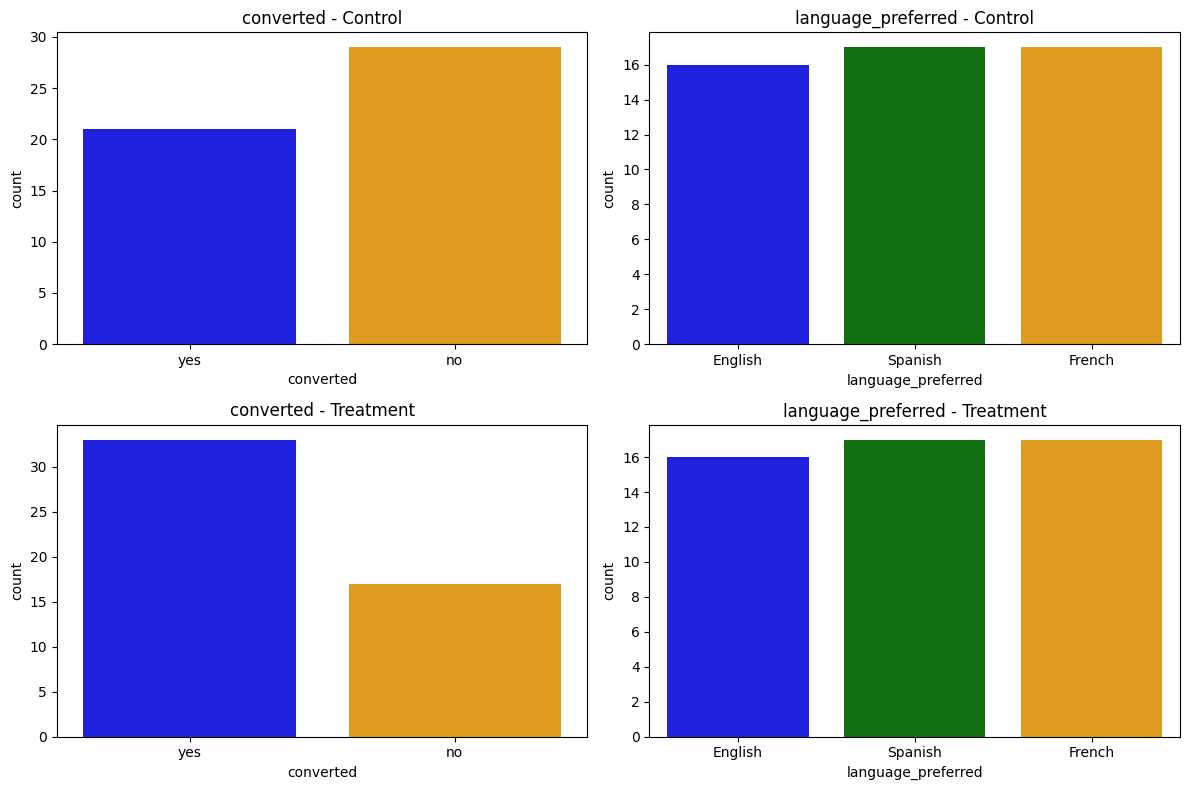

In [15]:
cat_columns_2 = ['converted', 'language_preferred']
plt.figure(figsize=(12, 8))

#these two items help the layout of the bar graphs to be consistent
col_map = {"English": "blue", "Spanish": "green", "French": "orange", "yes": "blue", "no": "orange"}
lang_order = ["English", "Spanish", "French"]

#looping through each of the categorical columns and creating a separate bargraph for each
for i, variable in enumerate(cat_columns_2):
    plt.subplot(2, 2, i + 1)
    current_order = ["yes", "no"] if variable == "converted" else lang_order
    sns.countplot(data = df[df['group']=="control"], x = variable, hue = variable, order = current_order, palette=col_map)
    plt.tight_layout()
    plt.title(variable + " - Control")

for i, variable in enumerate(cat_columns_2):
    plt.subplot(2, 2, i + 3)
    current_order = ["yes", "no"] if variable == "converted" else lang_order
    sns.countplot(data = df[df['group']=="treatment"], x = variable, hue = variable, order = current_order, palette=col_map)
    plt.tight_layout()
    plt.title(variable + " - Treatment")

plt.show()

In [16]:
#loop through each of the categorical columns separated by group and get the percentage of responses for each
for variable in cat_columns_2:
  print(f"{variable} - Control:  {df[df['group']=="control"][variable].value_counts(normalize=True)}")
  print(f"{variable} - Treatment:  {df[df['group']=="treatment"][variable].value_counts(normalize=True)}")

converted - Control:  converted
no     0.58
yes    0.42
Name: proportion, dtype: float64
converted - Treatment:  converted
yes    0.66
no     0.34
Name: proportion, dtype: float64
language_preferred - Control:  language_preferred
Spanish    0.34
French     0.34
English    0.32
Name: proportion, dtype: float64
language_preferred - Treatment:  language_preferred
Spanish    0.34
French     0.34
English    0.32
Name: proportion, dtype: float64


##### Data Insights
A slightly different pattern emerges in the categorical data when viewed sorted by groups.  In the control group, the conversion rate drops from the combined rate of 0.54 to 0.42 while the conversion rate for the Treatment group rises to 0.66.  This suggests (without yet running statistical analyses) that the new landing page is having a significant impact on conversion rate.  However, more analysis is needed.  There is no change at all in the language based on treatment type.

### Bivariate Analysis

#### Categorical Analysis
Since there is only one numeric variable, there is no bivariate numerical analysis.  Additionally, since the grouped data showed little change, this bivariate categorical analysis is going to look at the data grouped by treatment type.

In [17]:

#display the Two-way tables for each group
print("Two-Way Table for the Control Group")
control_two_way = pd.crosstab(df[df["group"] == "control"]['converted'], df[df["group"] == "control"]['language_preferred'])
print(control_two_way)
print("\nTwo-Way Table for the Treatment Group")
treat_two_way = pd.crosstab(df[df["group"] == "treatment"]['converted'], df[df["group"] == "treatment"]['language_preferred'])
print(treat_two_way)
#

Two-Way Table for the Control Group
language_preferred  English  French  Spanish
converted                                   
no                        5      14       10
yes                      11       3        7

Two-Way Table for the Treatment Group
language_preferred  English  French  Spanish
converted                                   
no                        6       5        6
yes                      10      12       11


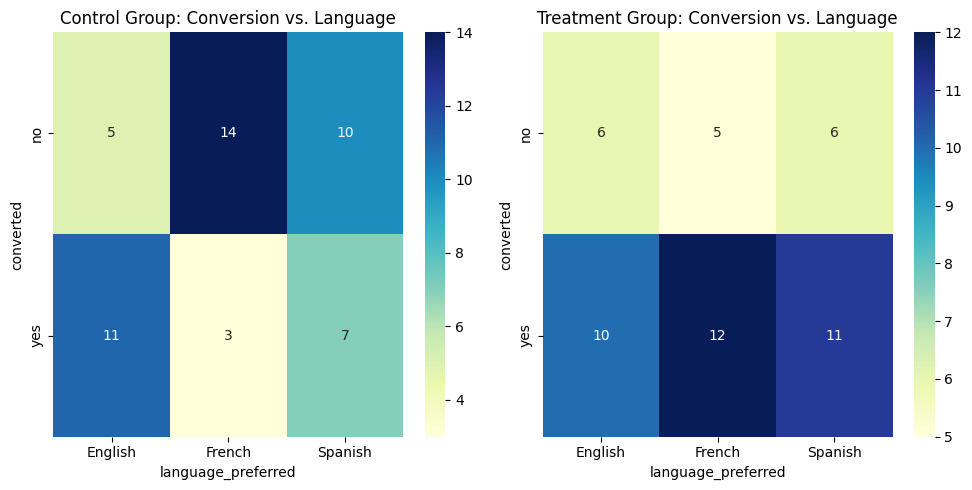

In [18]:
#Visualizing the two-way tables by creating heatmaps for each treatment group
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.heatmap(control_two_way, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Control Group: Conversion vs. Language')

plt.subplot(1, 2, 2)
sns.heatmap(treat_two_way, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Treatment Group: Conversion vs. Language')

plt.tight_layout()
plt.show()

#####Data Insights
Based on the two-way tables and heatmap, there is a clear distinction that appears between converted and language.  The count of conversions for English speakers are roughly identical regardless of the landing page.  However, the treatment group shows a much higher count of conversion rates for non-English (French and Spanish) speakers.

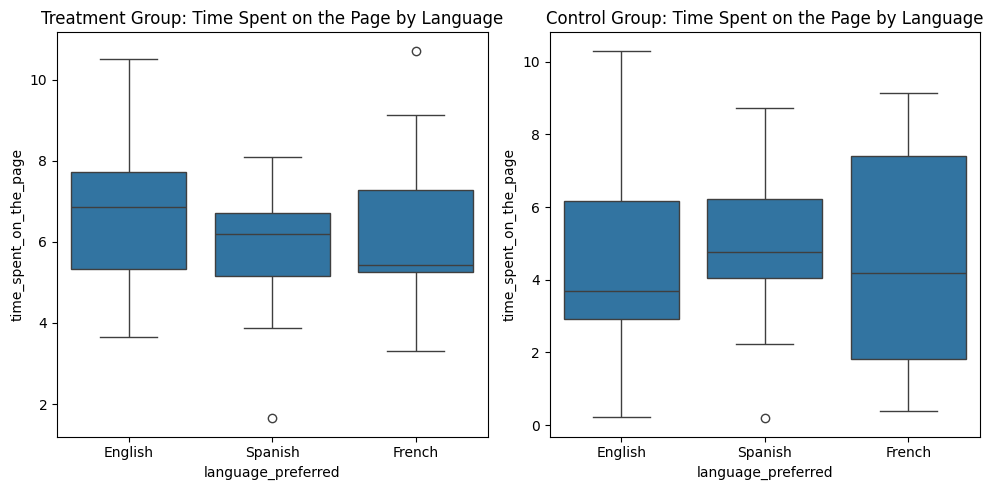

In [19]:
#display boxplots of language for time spent on the new page
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=treatment, x="language_preferred", y="time_spent_on_the_page", order = lang_order)
plt.title('Treatment Group: Time Spent on the Page by Language')
plt.subplot(1, 2, 2)
sns.boxplot(data=control, x="language_preferred", y="time_spent_on_the_page", order = lang_order)
plt.title('Control Group: Time Spent on the Page by Language')
plt.tight_layout()
plt.show()

##### Data Insights
When the average time spent on the page is categorized by preferred language, we see that the average amount of time on the page overlaps quite a bit when grouped by language.  This is true of both the treatment and control groups.  The only other notable difference is that the minimum amount of time spent on the pages were higher for all languages in the treatment group.  This provides circumstantial evidence that the newer landing page is slightly more engaging for all language users.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

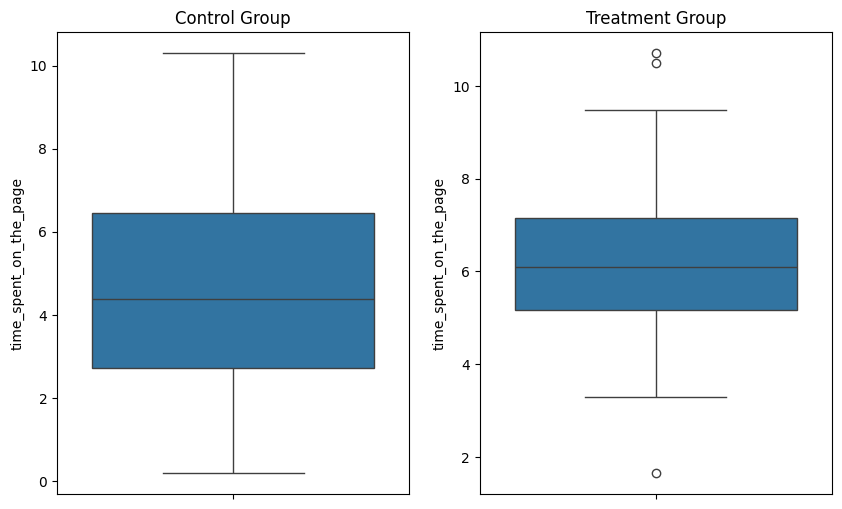

In [20]:
# plotting boxplots of the distribution of the time on the page
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
sns.boxplot(df[df["group"]=="control"]["time_spent_on_the_page"], ax=axes[0])
axes[0].set_title('Control Group')
sns.boxplot(df[df["group"]=="treatment"]["time_spent_on_the_page"], ax=axes[1])
axes[1].set_title('Treatment Group')
plt.show()

####Insights
The overall range of the two groups is similar; however, the mean of the treatment group is higher than that of the control group.The treatment group also contains some outliers that could affect the statistical results.

### Step 1: Define the null and alternate hypotheses

We will test the null hypothesis

Null hypothesis: the two groups have the same avearage time spent on the page.
>$H_0:$ $μ_1$ - $μ_2$ ≤ 0

against the alternate hypothesis
Alt hypothesis: The treatment group has a higher average than the control group.

>$H_0:$ $μ_1$ - $μ_2$ > 0


### Step 2: Select Appropriate test



I will perform a two-sample t-test for difference of means (or what the course called a two independent sample t-test for equality of means).  

**Assumptions**

* random selection: The data is randomly selected
* continuous data: the scale is continuous
* independence: the two groups are independent
* minimum sample size: each group meets the minimum sample size (n≥30) for the central limit theorem to apply
* variances do not appear to be equal, however we can still use Welch's t-test

### Step 3: Decide the significance level

For this test, and per the directions, we will use a signifiance level of $α$ = 0.05

### Step 4: Collect and prepare data

In [21]:
#separating data into two distinct groups for analysis
control_time = df[df["group"]=="control"]["time_spent_on_the_page"]
treatment_time = df[df["group"]=="treatment"]["time_spent_on_the_page"]

#running the t-test
t_stat, p_value = stats.ttest_ind(treatment_time, control_time, alternative="greater", equal_var=False)
alpha = 0.05


### Step 5: Calculate the p-value

In [22]:
#displaying results of the t-test
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

t-statistic: 3.7867702694199856
p-value: 0.0001392381225166549


### Step 6: Compare the p-value with $\alpha$

In [23]:
#boolean comparison (I honestly wasn't sure what to code for this step)
print(f"Is p-value, {p_value: .5f}, < alpha, {alpha}? {p_value < alpha}")

Is p-value,  0.00014, < alpha, 0.05? True


### Step 7:  Draw inference

Since the p-value is lower than alpha, we reject the null hypothesis.  We have convincing evidence to support the claim that the average time spent on the newer (treatment) landing page is significantly higher than the average time spent on the original landing page. To this end, the company may want to consider switching over to the newer landing page.

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Visual Analysis
This is copied from above.

Text(0.5, 1.0, 'Treatment Group')

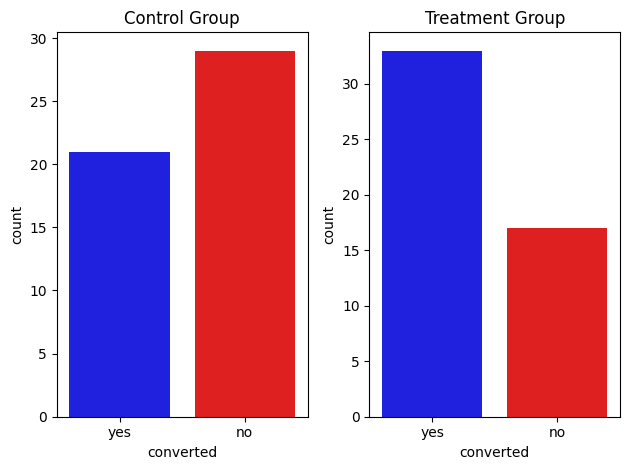

In [24]:
#showing bar graphs of the two groups' conversion counts
plt.subplot(1, 2, 1)
color_map = {"yes": "blue", "no": "red"}
#use of order and palette ensure consist layout
sns.countplot(data = control, x = "converted", hue = "converted", order = ['yes', 'no'], palette=color_map)
plt.tight_layout()
plt.title("Control Group")
plt.subplot(1, 2, 2)
sns.countplot(data = treatment, x = 'converted', hue = 'converted', order = ['yes', 'no'], palette=color_map)
plt.tight_layout()
plt.title("Treatment Group")

### Step 1: Define the null and alternate hypotheses
We will test the null hypothesis

Null hypothesis: the conversion rate proportion is the same between the two groups.
>$H_0:$ $p_1$ - $p_2$ ≤ 0

against the alternate hypothesis
Alt hypothesis: The treatment group has a higher average than the control group.

>$H_0:$ $p_1$ - $p_2$ > 0


### Step 2: Select Appropriate test

I will perform a two-sample z-test for difference of proportions (or what the course called a two proportion z-test).

**Assumptions**

* Binomally distributed population - Yes, a user is tagged as either converted or not converted
* Random sampling from the population - Yes, we are informed that the collected sample is a simple random sample.
* Can the binomial distribution approximated to normal distribution - Yes.

>$np_1 = 50\cdot 0.42 =21 \geq 10\\
n(1-p_1) = 50 \cdot (1-0.42) =29 \geq 10 \\
np_2 = 50\cdot 0.66 =33 \geq 10\\
n(1-p_2) = 50 \cdot (1-0.66) =17 \geq 10 $

### Step 3: Decide the significance level

For this test, and per the directions, we will use a signifiance level of $α$ = 0.05

### Step 4: Collect and prepare data

In [25]:
#storing data into variable for ease of use
#count = number of obserations
#con_suc = number of successes in control group
#treat_suc = number of successes in treatment group

count = 50
con_suc = 21
treat_suc = 33
test_stat, p_val = proportions_ztest([treat_suc, con_suc], [count, count], alternative="larger")

###Step 5: Report Test Statistic and compare p-value to alpha

In [26]:
#Displaying results
print(f"test statistic: {test_stat}")
print(f"p-value: {p_val}")
print(f"Is the p-value, {p_val:.3f}, less than alpha {alpha}? {p_val < alpha}")

test statistic: 2.4077170617153842
p-value: 0.008026308204056278
Is the p-value, 0.008, less than alpha 0.05? True


### Step 6: Draw Inferences
Since the p-value is less than our significance level, we reject the null hypothesis.  We have convincing evidence that the proportion of conversions to a paid account are signficantly higher for the new landing page than for the old one.  As a result, the company should push out the new layout to all users.

## 3. Is the conversion and preferred language are independent or related?

### Data Visualization
This was performed above.  Reference the heatmaps.

### Step 1: Define the null and alternate hypotheses
This test will be run separately on each treatment group.  For each, we will test the null hypothesis

$H_0$: the conversion rate is independent of language

against the alternate hypothesis

$H_a$: the conversion rate is related to the language of the webpage.



### Step 2: Select Appropriate test

I will perform a Chi-Square test for independence since this is categorical data.

**Assumptions**

* Categorical data - yes
* Random - yes, the sample is drawn at random
* Expected counts greater than 5 - yes, but they are very close to the cutoff value of 5.  Thus, we must proceed with caution when interpreting our results.  I will use Yates' continuity correction since the expected counts are small.

### Step 3: Decide the significance level

For this test, and per the directions, we will use a signifiance level of $α$ = 0.05

### Step 4: Collect and prepare data

In [27]:
treat_stat, p_treat, dof, treat_expected = stats.chi2_contingency(treat_two_way, correction=True)
control_stat, p_control, dof, control_expected = stats.chi2_contingency(control_two_way, correction=True)

### Step 5: Report statistics and compare p-values to alpha

In [28]:
#Print expected counts to verify test conditions
print("Treatment Group expected counts\n", treat_expected)
print("\nControl Group expected counts\n", control_expected)
print()

#Printing test results
print(f"Degrees of Freedom for Treatment Group: {dof}")
print(f"Degrees of Freedom for Control Group: {dof}")
print()
print(f"Test Statistic for Treatment Group: {treat_stat}")
print(f"Test Statistic for Control Group: {control_stat}")
print()
print(f"p-value for Treatment Group: {p_treat}")
print(f"p-value for Control Group: {p_control}")

Treatment Group expected counts
 [[ 5.44  5.78  5.78]
 [10.56 11.22 11.22]]

Control Group expected counts
 [[9.28 9.86 9.86]
 [6.72 7.14 7.14]]

Degrees of Freedom for Treatment Group: 2
Degrees of Freedom for Control Group: 2

Test Statistic for Treatment Group: 0.259515570934256
Test Statistic for Control Group: 8.843451173572877

p-value for Treatment Group: 0.8783081441552572
p-value for Control Group: 0.012013484079071492


### Step 6: Draw Inferences
For the treatment group the p-value was greater than the significance level.  For this group, we fail to reject the null hypothesis.  The language of choice of the user appears to be independent of the conversion rate.  

For the control group, the p-value was less than the significance level.  As a result, there is a relationship between conversion rate and language.  For the original landing page, there was a significantly higher conversion rate for English users and a significantly lower conversion rate for French and Spanish users than expected.

As with the analyses above, this strongly suggests that the new (treatment) landing page is better at meeting the business' needs.

## 4. Is the time spent on the new page same for the different language users?

### Data Visualization

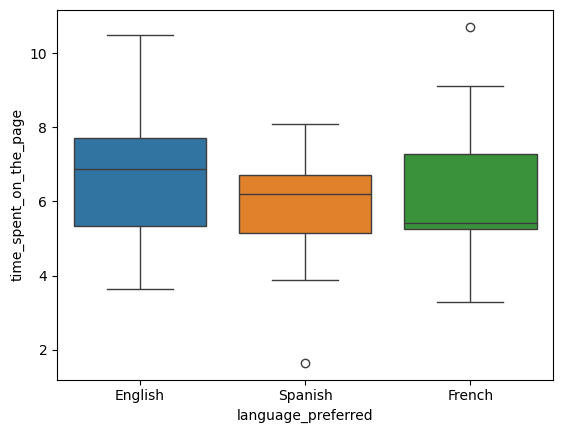

In [29]:
#display counts of language for time spent on the new page
sns.boxplot(data=treatment, x="language_preferred", y="time_spent_on_the_page", hue = "language_preferred", order = lang_order)
plt.show()


In [30]:
#Calculating the standard deviation of each subgroup to verify equal variances
eng_stdev = stats.tstd(treatment[treatment["language_preferred"]=="English"]["time_spent_on_the_page"])
fre_stdev = stats.tstd(treatment[treatment["language_preferred"]=="French"]["time_spent_on_the_page"])
spa_stdev = stats.tstd(treatment[treatment["language_preferred"]=="Spanish"]["time_spent_on_the_page"])

print(f"English Standard Deviation: {eng_stdev:.3f}")
print(f"French Standard Deviation: {fre_stdev:.3f}")
print(f"Spanish Standard Deviation: {spa_stdev:.3f}")


English Standard Deviation: 1.984
French Standard Deviation: 1.933
Spanish Standard Deviation: 1.526


### Step 1: Define the null and alternate hypotheses
We will test the null hypothesis that the mean amount of time spent on the new page is the same for all languages

$H_0$: $μ_1 = μ_2 = μ_3$

against the alternate hypothesis that the mean amount of time spent on all pages is different for at least one of the languages

$H_a$: $μ_1 \ne μ_2 \ne μ_3$



### Step 2: Select Appropriate test

I will perform an Analysis of Variance (ANOVA) since this is more than two quantitative subgroups (or means across more than 2 categories).

**Assumptions**

* Normality - yes, each boxplot is approximately normal
* Equality of Variances - yes, the standard deviation of each subgroup is very similary implying that the variances are approximately equal
(both assumptions tested below)

### Step 3: Decide the significance level

For this test, and per the directions, we will use a signifiance level of $α$ = 0.05

### Step 4: Prepare the data for analysis

#### **Shapiro-Wilkes Test**
This tests the normality condition

In [31]:
# Assumption 1: Normality
# Use the shapiro function for the scipy.stats library for this test

# find the p-value
w, p_value = stats.shapiro(treatment["time_spent_on_the_page"])
print('The p-value is', p_value)

The p-value is 0.8040040364746845


##### Interpretation
Since the p-value is large compared to the significance level of 0.05, we fail to reject the null hypothesis that the data is normal.  The normality assumption is met

#### **Levene's Test**
This tests the equality of variance assumption.

We will test the null hypothesis

>$H_0$: All the population variances are equal

against the alternative hypothesis

>$H_a$: At least one variance is different from the rest

In [32]:
#Assumption 2: Homogeneity of Variance
# use levene function from scipy.stats library for this test

# find the p-value
statistic, p_value = stats.levene(treatment["language_preferred"]=="English", treatment["language_preferred"]=="French", treatment["language_preferred"]=="Spanish")
print('The p-value is', p_value)

The p-value is 0.9710222644330399


##### Interpretation
Since the p-value is large compared to the significance level of 0.05, we fail to reject the null hypothesis.  The homogeneity of variances assumption is met.

### Step 5: Report the statistics and compare p-value to alpha

In [33]:
#separate out the different times by language for the treatment group
treat_eng_time = treatment[treatment["language_preferred"]=="English"]["time_spent_on_the_page"]
treat_fre_time = treatment[treatment["language_preferred"]=="French"]["time_spent_on_the_page"]
treat_spa_time = treatment[treatment["language_preferred"]=="Spanish"]["time_spent_on_the_page"]

#calculate and display the ANOVA results
f_stat, p_val = stats.f_oneway(treat_eng_time, treat_fre_time, treat_spa_time)
print(f"f-statistic: {f_stat}")
print(f"p-value: {p_val}")

f-statistic: 0.8543992770006822
p-value: 0.43204138694325955


### Step 6: Draw Inferences

Since the p-value is greater than the significance level of 5% (0.05) we fail to reject the null hypothesis.  We have no evidence to support the claim that there is a difference between the amount of time spent on the new page among different language speakers.  This suggests that the new landing page's display language has no direct impact on the amount of time user spend on it.

## Conclusion and Business Recommendations

In conclusion, it is abundantly clear that the new landing page will have a significant positive impact on users.  Compared to the old version, the new version has significantly higher time spent on page for all language users and there is a higher conversion rate to paid customers for the new verion of the landing page.  Additionally, the new landing page appears to remove some sort of unidentified language bias that was occuring on the old version. There was a relationship between conversions and language with the old version that is no longer present with the new version.  

As a result, I recommend that the business move to immediately push out the new landing page for all customers.

___